# Supplementary Figure S3C — Per-parameter penalty weights

Relative weight of each scored parameter.

In [1]:
import json
from pathlib import Path
import matplotlib.pyplot as plt

_ROOT = Path.cwd().parent.parent
FIGURES = _ROOT / "figures"

def data_file(rel):
    return _ROOT / "data" / rel

def savefig(fig, name, dpi=150):
    FIGURES.mkdir(exist_ok=True)
    fig.savefig(FIGURES / name, dpi=dpi, bbox_inches="tight")
    return Path("figures") / name

In [2]:
WEIGHTS = json.load(open(data_file("reference/scoring_tables/penalty_weights.json")))["penalty_weights"]

saved figures/figS3_C_penalty_weights.png


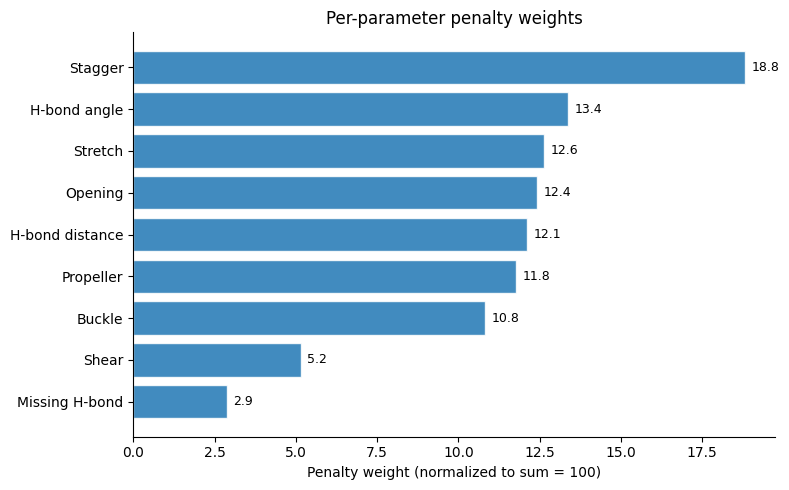

In [3]:
LABEL = {"stagger": "Stagger", "hbond_angles": "H-bond angle", "stretch": "Stretch",
         "opening": "Opening", "distance": "H-bond distance", "propeller": "Propeller",
         "buckle": "Buckle", "shear": "Shear", "incorrect_hbond_count": "Missing H-bond"}
items = sorted(WEIGHTS.items(), key=lambda kv: kv[1])
names = [LABEL.get(k, k) for k, _ in items]
vals = [v for _, v in items]
fig, ax = plt.subplots(figsize=(8, 5))
ax.barh(names, vals, color="tab:blue", alpha=0.85, edgecolor="white")
ax.set_xlabel("Penalty weight (normalized to sum = 100)")
ax.set_title("Per-parameter penalty weights")
for i, v in enumerate(vals):
    ax.text(v + 0.2, i, f"{v:.1f}", va="center", fontsize=9)
ax.spines[["top", "right"]].set_visible(False)
fig.tight_layout()
print("saved", savefig(fig, "figS3_C_penalty_weights.png"))
plt.show()